# Kohonen Map - Colors RGB

**Dataset** : Colors RGB (points RGB normalises dans [0, 1] regroupes en familles de couleurs).  
**Objectif** : apprentissage non supervise avec une carte de Kohonen, selection des hyperparametres sur validation explicite, puis evaluation sur test.  

**Specificites sur ce dataset** :
- Les entrees sont des triplets RGB.
- La carte de Kohonen apprend une grille de prototypes qui resume les couleurs.
- La validation sert a choisir la taille de la carte, le rayon initial et le taux d'apprentissage.

Dataset complet : 1440 echantillons
Train : 1008 | Validation : 216 | Test : 216
Nombre de classes couleurs : 8


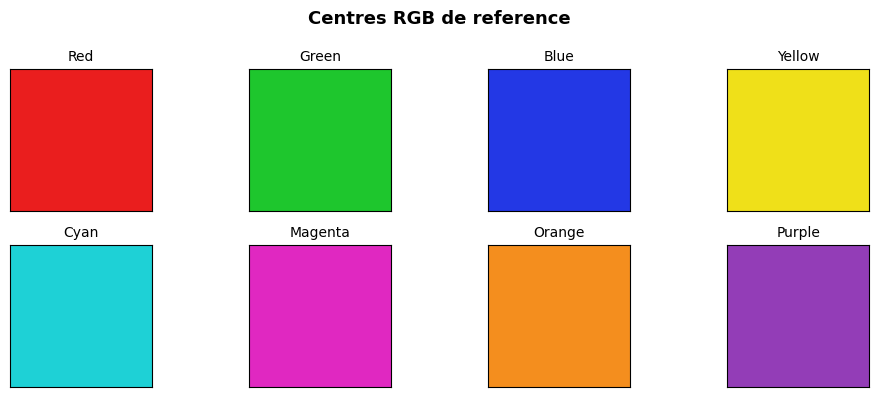

Variance expliquee par la PCA 2D : 0.912


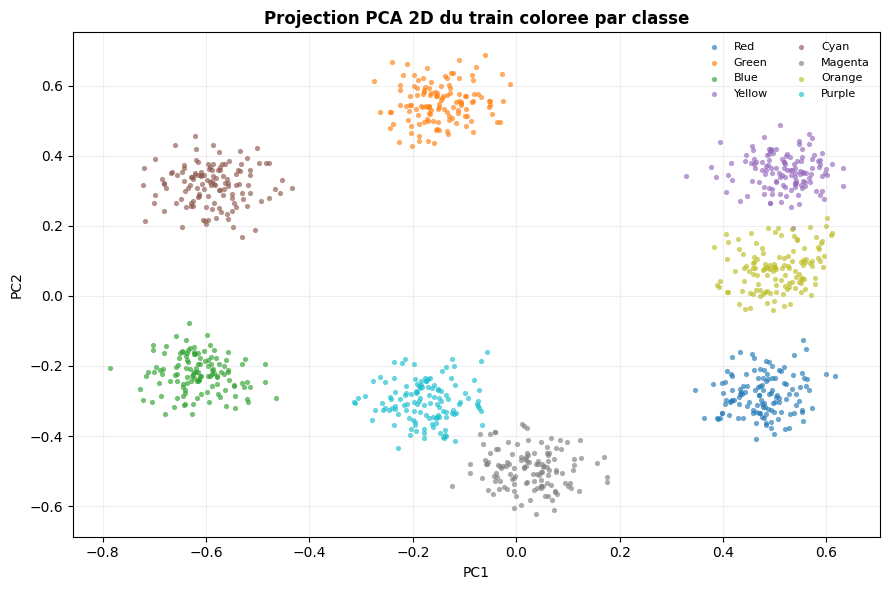

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Dataset Colors RGB : familles de couleurs dans l'espace RGB normalise
color_centers = {
    'Red': np.array([0.92, 0.12, 0.12]),
    'Green': np.array([0.12, 0.78, 0.18]),
    'Blue': np.array([0.14, 0.22, 0.90]),
    'Yellow': np.array([0.94, 0.88, 0.10]),
    'Cyan': np.array([0.12, 0.82, 0.84]),
    'Magenta': np.array([0.88, 0.16, 0.76]),
    'Orange': np.array([0.96, 0.56, 0.12]),
    'Purple': np.array([0.58, 0.24, 0.72]),
}

samples_per_class = 180
noise_std = 0.055

X_parts = []
y_parts = []
label_names = list(color_centers.keys())

for label_idx, name in enumerate(label_names):
    center = color_centers[name]
    samples = center + noise_std * np.random.randn(samples_per_class, 3)
    samples = np.clip(samples, 0.0, 1.0)
    X_parts.append(samples)
    y_parts.append(np.full(samples_per_class, label_idx, dtype=int))

X = np.vstack(X_parts)
y = np.concatenate(y_parts)

# Split explicite train / validation / test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y, shuffle=True
 )
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp, shuffle=True
 )

print(f"Dataset complet : {X.shape[0]} echantillons")
print(f"Train : {X_train.shape[0]} | Validation : {X_val.shape[0]} | Test : {X_test.shape[0]}")
print(f"Nombre de classes couleurs : {len(label_names)}")

# Apercu des couleurs moyennes du dataset
fig, axes = plt.subplots(2, 4, figsize=(10, 4), facecolor='white')
for ax, name in zip(axes.ravel(), label_names):
    swatch = np.ones((18, 18, 3)) * color_centers[name]
    ax.imshow(swatch)
    ax.set_title(name, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle('Centres RGB de reference', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Projection 2D pour visualiser la structure du nuage RGB
pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train)
X_val_2d = pca_2d.transform(X_val)
X_test_2d = pca_2d.transform(X_test)

print(f"Variance expliquee par la PCA 2D : {pca_2d.explained_variance_ratio_.sum():.3f}")

fig, ax = plt.subplots(figsize=(9, 6), facecolor='white')
palette = plt.cm.tab10(np.linspace(0, 1, len(label_names)))
for class_idx, name in enumerate(label_names):
    mask = y_train == class_idx
    ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], s=14, alpha=0.65, label=name, color=palette[class_idx], linewidths=0)
ax.set_title('Projection PCA 2D du train coloree par classe', fontsize=12, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.grid(alpha=0.2)
ax.legend(ncol=2, fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

In [2]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, accuracy_score

class KohonenMap:
    def __init__(self, n_rows, n_cols, input_dim, learning_rate=0.4, sigma=None, n_epochs=25, random_state=42):
        self.n_rows = n_rows
        self.n_cols = n_cols
        self.input_dim = input_dim
        self.learning_rate = learning_rate
        self.sigma = sigma if sigma is not None else max(n_rows, n_cols) / 2.0
        self.n_epochs = n_epochs
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)
        self.weights = self.rng.random((n_rows, n_cols, input_dim))
        self._grid = np.array([(i, j) for i in range(n_rows) for j in range(n_cols)], dtype=float)
        self._grid = self._grid.reshape(n_rows, n_cols, 2)

    def _bmu_index(self, sample):
        distances = np.sum((self.weights - sample) ** 2, axis=2)
        flat_index = np.argmin(distances)
        return np.unravel_index(flat_index, distances.shape), float(np.min(distances))

    def _learning_rate(self, step, total_steps):
        progress = step / max(1, total_steps - 1)
        return self.learning_rate * np.exp(-progress)

    def _sigma(self, step, total_steps):
        progress = step / max(1, total_steps - 1)
        return max(0.35, self.sigma * np.exp(-progress))

    def fit(self, X):
        total_steps = self.n_epochs * len(X)
        step = 0
        for _ in range(self.n_epochs):
            for idx in self.rng.permutation(len(X)):
                sample = X[idx]
                (bmu_row, bmu_col), _ = self._bmu_index(sample)
                lr = self._learning_rate(step, total_steps)
                sigma = self._sigma(step, total_steps)
                grid_distance_sq = (self._grid[:, :, 0] - bmu_row) ** 2 + (self._grid[:, :, 1] - bmu_col) ** 2
                influence = np.exp(-grid_distance_sq / (2.0 * sigma ** 2))[..., np.newaxis]
                self.weights += lr * influence * (sample - self.weights)
                step += 1
        return self

    def bmu_indices(self, X):
        bmus = []
        distances = []
        for sample in X:
            (row, col), dist = self._bmu_index(sample)
            bmus.append((row, col))
            distances.append(dist)
        return np.asarray(bmus, dtype=int), np.asarray(distances, dtype=float)

    def predict_neuron_ids(self, X):
        bmus, _ = self.bmu_indices(X)
        return bmus[:, 0] * self.n_cols + bmus[:, 1]

    def quantization_error(self, X):
        _, distances = self.bmu_indices(X)
        return float(np.mean(np.sqrt(distances)))


def neuron_majority_mapping(neuron_ids, y_true):
    mapping = {}
    for neuron_id in np.unique(neuron_ids):
        mask = neuron_ids == neuron_id
        counts = np.bincount(y_true[mask], minlength=len(label_names))
        mapping[int(neuron_id)] = int(np.argmax(counts))
    default_label = int(np.bincount(y_true, minlength=len(label_names)).argmax())
    return mapping, default_label


def map_neurons_to_labels(neuron_ids, mapping, default_label):
    return np.array([mapping.get(int(neuron_id), default_label) for neuron_id in neuron_ids], dtype=int)


def evaluate_model(model, X_eval, y_eval, neuron_mapping, default_label):
    neuron_ids = model.predict_neuron_ids(X_eval)
    y_pred = map_neurons_to_labels(neuron_ids, neuron_mapping, default_label)
    qe = model.quantization_error(X_eval)
    dead_ratio = 1.0 - (len(np.unique(model.predict_neuron_ids(X_train))) / (model.n_rows * model.n_cols))
    return {
        'ari': float(adjusted_rand_score(y_eval, y_pred)),
        'nmi': float(normalized_mutual_info_score(y_eval, y_pred)),
        'accuracy': float(accuracy_score(y_eval, y_pred)),
        'quantization_error': qe,
        'dead_ratio': float(dead_ratio),
        'y_pred': y_pred,
        'neuron_ids': neuron_ids,
    }


def validation_score(metrics):
    qe_norm = metrics['quantization_error'] / np.sqrt(3.0)
    score = (
        0.45 * metrics['ari']
        + 0.35 * metrics['nmi']
        + 0.15 * metrics['accuracy']
        - 0.05 * qe_norm
        - 0.03 * metrics['dead_ratio']
    )
    return score


grid_grid = [(5, 5), (6, 6), (7, 7)]
learning_rate_grid = [0.25, 0.40, 0.55]
sigma_grid = [1.2, 1.8, 2.6]
epoch_grid = [18, 28]

results = []
trial = 0
total = len(grid_grid) * len(learning_rate_grid) * len(sigma_grid) * len(epoch_grid)

print(f"Nombre total d'essais SOM : {total}")

for n_rows, n_cols in grid_grid:
    for learning_rate in learning_rate_grid:
        for sigma in sigma_grid:
            for n_epochs in epoch_grid:
                trial += 1
                som = KohonenMap(
                    n_rows=n_rows,
                    n_cols=n_cols,
                    input_dim=X_train.shape[1],
                    learning_rate=learning_rate,
                    sigma=sigma,
                    n_epochs=n_epochs,
                    random_state=42,
                )
                som.fit(X_train)

                train_neurons = som.predict_neuron_ids(X_train)
                neuron_mapping, default_label = neuron_majority_mapping(train_neurons, y_train)

                val_metrics = evaluate_model(som, X_val, y_val, neuron_mapping, default_label)
                score = validation_score(val_metrics)

                result = {
                    'trial': trial,
                    'n_rows': n_rows,
                    'n_cols': n_cols,
                    'learning_rate': learning_rate,
                    'sigma': sigma,
                    'n_epochs': n_epochs,
                    'score_val': score,
                    'metrics_val': val_metrics,
                }
                results.append(result)

                print(
                    f"Essai {trial}/{total} | score={score:.4f} | ARI={val_metrics['ari']:.4f} | "
                    f"NMI={val_metrics['nmi']:.4f} | ACC={val_metrics['accuracy']:.4f} | "
                    f"QE={val_metrics['quantization_error']:.4f} | grid={n_rows}x{n_cols} | "
                    f"lr={learning_rate:.2f} | sigma={sigma:.1f} | epochs={n_epochs}"
                )

best_result = max(results, key=lambda item: item['score_val'])
print('\nMeilleur modele selectionne sur validation :')
print(best_result)

Nombre total d'essais SOM : 54
Essai 1/54 | score=0.9253 | ARI=0.9789 | NMI=0.9840 | ACC=0.9907 | QE=0.0786 | grid=5x5 | lr=0.25 | sigma=1.2 | epochs=18
Essai 2/54 | score=0.9305 | ARI=0.9893 | NMI=0.9904 | ACC=0.9954 | QE=0.0769 | grid=5x5 | lr=0.25 | sigma=1.2 | epochs=28
Essai 3/54 | score=0.9239 | ARI=0.9789 | NMI=0.9840 | ACC=0.9907 | QE=0.0839 | grid=5x5 | lr=0.25 | sigma=1.8 | epochs=18
Essai 4/54 | score=0.9264 | ARI=0.9789 | NMI=0.9840 | ACC=0.9907 | QE=0.0818 | grid=5x5 | lr=0.25 | sigma=1.8 | epochs=28
Essai 5/54 | score=0.9294 | ARI=0.9893 | NMI=0.9904 | ACC=0.9954 | QE=0.1147 | grid=5x5 | lr=0.25 | sigma=2.6 | epochs=18
Essai 6/54 | score=0.9118 | ARI=0.9682 | NMI=0.9744 | ACC=0.9861 | QE=0.1119 | grid=5x5 | lr=0.25 | sigma=2.6 | epochs=28
Essai 7/54 | score=0.9252 | ARI=0.9789 | NMI=0.9840 | ACC=0.9907 | QE=0.0793 | grid=5x5 | lr=0.40 | sigma=1.2 | epochs=18
Essai 8/54 | score=0.9317 | ARI=0.9893 | NMI=0.9904 | ACC=0.9954 | QE=0.0778 | grid=5x5 | lr=0.40 | sigma=1.2 | epo

In [ ]:
from sklearn.metrics import confusion_matrix

# Entrainement final sur train + validation, puis evaluation sur test
X_fit = np.vstack([X_train, X_val])
y_fit = np.concatenate([y_train, y_val])

final_som = KohonenMap(
    n_rows=best_result['n_rows'],
    n_cols=best_result['n_cols'],
    input_dim=X_fit.shape[1],
    learning_rate=best_result['learning_rate'],
    sigma=best_result['sigma'],
    n_epochs=best_result['n_epochs'],
    random_state=42,
 )
final_som.fit(X_fit)

fit_neurons = final_som.predict_neuron_ids(X_fit)
fit_mapping, fit_default_label = neuron_majority_mapping(fit_neurons, y_fit)

test_neurons = final_som.predict_neuron_ids(X_test)
y_test_pred = map_neurons_to_labels(test_neurons, fit_mapping, fit_default_label)

test_metrics = {
    'ari': float(adjusted_rand_score(y_test, y_test_pred)),
    'nmi': float(normalized_mutual_info_score(y_test, y_test_pred)),
    'accuracy': float(accuracy_score(y_test, y_test_pred)),
    'quantization_error': float(final_som.quantization_error(X_test)),
    'active_neurons': int(len(np.unique(test_neurons))),
    'total_neurons': int(final_som.n_rows * final_som.n_cols),
}

print('Protocole: hyperparametres selectionnes sur validation, puis reentrainement sur train + validation')
print('Evaluation finale sur TEST')
print(f"Carte retenue : {final_som.n_rows} x {final_som.n_cols}")
print(f"Accuracy : {test_metrics['accuracy']:.4f}")
print(f"ARI : {test_metrics['ari']:.4f}")
print(f"NMI : {test_metrics['nmi']:.4f}")
print(f"Quantization error : {test_metrics['quantization_error']:.4f}")
print(f"Neurones actifs sur test : {test_metrics['active_neurons']} / {test_metrics['total_neurons']}")

cm = confusion_matrix(y_test, y_test_pred)
print('\nMatrice de confusion (classes vraies x classes predies) :')
print(cm)

Protocole: hyperparametres selectionnes sur validation, puis reentrainement sur train + validation
Evaluation finale sur TEST (une seule fois)
Carte retenue : 6 x 6
Accuracy : 1.0000
ARI : 1.0000
NMI : 1.0000
Quantization error : 0.0714
Neurones actifs sur test : 26 / 36

Matrice de confusion (classes vraies x classes predies) :
[[27  0  0  0  0  0  0  0]
 [ 0 27  0  0  0  0  0  0]
 [ 0  0 27  0  0  0  0  0]
 [ 0  0  0 27  0  0  0  0]
 [ 0  0  0  0 27  0  0  0]
 [ 0  0  0  0  0 27  0  0]
 [ 0  0  0  0  0  0 27  0]
 [ 0  0  0  0  0  0  0 27]]


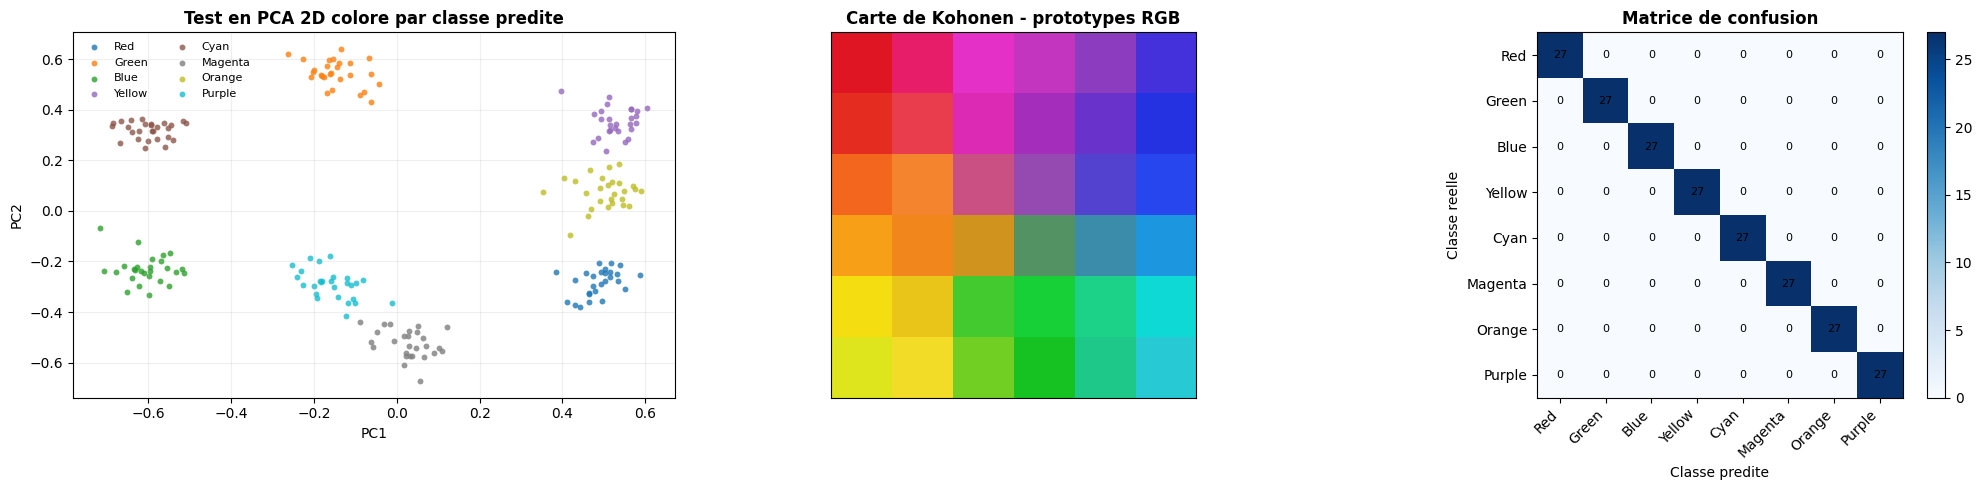

In [4]:
# Visualisations : projection du test, carte de prototypes et matrice de confusion
fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor='white')

# Projection PCA 2D des points de test, colores par classe predite
palette = plt.cm.tab10(np.linspace(0, 1, len(label_names)))
for class_idx, name in enumerate(label_names):
    mask = y_test_pred == class_idx
    axes[0].scatter(
        X_test_2d[mask, 0],
        X_test_2d[mask, 1],
        s=18,
        alpha=0.8,
        label=name,
        color=palette[class_idx],
        linewidths=0,
    )
axes[0].set_title('Test en PCA 2D colore par classe predite', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(alpha=0.2)
axes[0].legend(ncol=2, fontsize=8, frameon=False)

# Carte de Kohonen : chaque neurone est visualise par son prototype RGB
axes[1].imshow(np.clip(final_som.weights, 0, 1), interpolation='nearest')
axes[1].set_title('Carte de Kohonen - prototypes RGB', fontsize=12, fontweight='bold')
axes[1].set_xticks([])
axes[1].set_yticks([])

# Matrice de confusion
im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_title('Matrice de confusion', fontsize=12, fontweight='bold')
axes[2].set_xticks(np.arange(len(label_names)))
axes[2].set_yticks(np.arange(len(label_names)))
axes[2].set_xticklabels(label_names, rotation=45, ha='right')
axes[2].set_yticklabels(label_names)
axes[2].set_xlabel('Classe predite')
axes[2].set_ylabel('Classe reelle')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        axes[2].text(j, i, str(value), ha='center', va='center', color='black', fontsize=8)

fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()